In [26]:
"""
Summing log probabilities is standard approach in machine learning and AI.
As apposed to the sum of the linear product: torch.prod() -> torch.softmax()

Instead Favor:
torch.sum()
torch.log_softmax()
"""

'\nSumming log probabilities is standard approach in machine learning and AI.\nAs apposed to the sum of the linear product: torch.prod() -> torch.softmax()\n\nInstead Favor:\ntorch.sum()\ntorch.log_softmax()\n'

In [2]:
import torch
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import load_model_and_tokenizer

device = get_device()
device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


In [3]:
from reasoning_from_scratch.ch03 import render_prompt
from reasoning_from_scratch.ch04 import (
    generate_text_stream_concat_flex,
    generate_text_top_p_stream_cache
)

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)
prompt_cot = prompt + "\n\nExplain step by step."

torch.manual_seed(0)
response_1 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9
)

 ### Step 1: Understand the problem

The problem states that half the value of \(3x - 9\) is equal to \(x + 37\). We need to find the value of \(x\).

### Step 2: Translate the problem into an equation

Let's translate the given statement into an equation. Half of \(3x - 9\) is equal to \(x + 37\).

\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 3: Solve the equation

To solve for \(x\), we'll first eliminate the fraction by multiplying both sides of the equation by 2:

\[
2 \times \frac{1}{2}(3x - 9) = 2 \times (x + 37)
\]

This simplifies to:

\[
3x - 9 = 2x + 74
\]

### Step 4: Isolate the variable \(x\)

Now, we'll isolate \(x\) by subtracting \(2x\) from both sides of the equation:

\[
3x - 2x - 9 = 74
\]

Simplifying this, we get:

\[
x - 9 = 74
\]

### Step 5: Solve for \(x\)

Next, we'll add 9 to both sides to solve for \(x\):

\[
x - 9 + 9 = 74 + 9
\]

This simplifies to:

\[
x = 83
\]

### Step 6: Verify the solution

To ensure our solution is correct, we'll substitute \(x = 83

In [4]:
torch.manual_seed(3)
response_2 = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.9,
    top_p=0.9,
)

 We start with the equation:

\[
\frac{1}{2} \times (3x - 9) = x + 37
\]

Step 1: Multiply both sides of the equation by 2 to eliminate the fraction:

\[
2 \times \frac{1}{2} \times (3x - 9) = 2 \times (x + 37)
\]

Simplifying both sides:

\[
3x - 9 = 2x + 74
\]

Step 2: Subtract \(2x\) from both sides to get all the \(x\) terms on one side:

\[
3x - 2x - 9 = 74
\]

Simplifying:

\[
x - 9 = 74
\]

Step 3: Add 9 to both sides to isolate \(x\):

\[
x - 9 + 9 = 74 + 9
\]

Simplifying:

\[
x = 83
\]

Final Answer:

\[
\boxed{83}
\]

In [5]:
print("Response 1 characters:", len(response_1))
print("Response 1 tokens:", len(tokenizer.encode(response_1)))
print("\nResponse 2 characters:", len(response_2))
print("response 2 tokens:", len(tokenizer.encode(response_2)))

Response 1 characters: 1419
Response 1 tokens: 534

Response 2 characters: 533
response 2 tokens: 231


In [6]:
from reasoning_from_scratch.ch03 import extract_final_candidate
import math

def heuristic_score(
    answer,
    prompt=None,
    brevity_bonus=500.0,
    boxed_bonus=2.0,
    extract_bonus=1.0,
    fulltext_bonus=0.0,
):
    score = 0.0
    cand = extract_final_candidate(answer, fallback="none") # reward answers with final boxed value
    if cand:
        score += boxed_bonus
    else:
        cand = extract_final_candidate(answer, fallback="number_only")
        if cand:
            score += extract_bonus
        else:
            cand = extract_final_candidate(answer, fallback="number_then_full")
            if cand:
                score += fulltext_bonus
                
    score += 1.5 * math.exp(-len(answer) / brevity_bonus) # brevity reward decays with text length
    return score

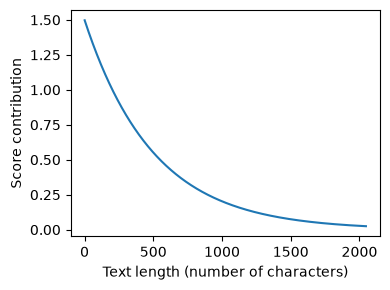

In [7]:
import matplotlib.pyplot as plt

def plot_brevity_curve(brevity_bonus, max_len=2048):
    lengths = torch.arange(1, max_len)
    scores = 1.5 * torch.exp(-lengths / brevity_bonus)
    
    plt.figure(figsize=(4, 3))
    plt.plot(lengths, scores)
    plt.xlabel("Text length (number of characters)")
    plt.ylabel("Score contribution")
    plt.tight_layout()
    plt.show()

plot_brevity_curve(500)

In [8]:
print(round(heuristic_score(response_1), 3))

2.088


In [9]:
print(round(heuristic_score(response_2), 3))

2.517


In [12]:
@torch.inference_mode()
def calc_next_token_probas(model, tokenizer, prompt, device, show=True):
    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)
    
    logits = model(token_ids.unsqueeze(0)).squeeze(0)
    # each sequence position, operate across all 151,936 vocabulary scores
    all_probas = torch.softmax(logits, dim=-1) # [sequence, vocab] dim=-1 = vocab

    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)
    
    next_ids = token_ids[1:]
    # get probabilities for each next token
    next_token_probas = all_probas[t_idx, next_ids]
    # likelihood of the sequnce is the product of the probability scores
    prod_next_token_probas = torch.prod(next_token_probas)

    if show:
        print("Next-token probabilities:", next_token_probas)
        print("Joint probability:", prod_next_token_probas)
    else:
        return next_token_probas, prod_next_token_probas

In [13]:
torch.set_printoptions(precision=4, sci_mode=True)
calc_next_token_probas(
    model, tokenizer, device=device,
    prompt="The capital of Japan is Tokyo"
)

Next-token probabilities: tensor([6.1512e-05, 4.6484e-01, 1.8921e-02, 7.0703e-01, 4.6484e-01],
       dtype=torch.bfloat16)
Joint probability: tensor(1.7788e-07, dtype=torch.bfloat16)


In [15]:
calc_next_token_probas(
    model, tokenizer, device=device,
    prompt="The capital of Japan is Osaka"
)

Next-token probabilities: tensor([6.1512e-05, 4.6484e-01, 1.8921e-02, 7.0703e-01, 9.6436e-03],
       dtype=torch.bfloat16)
Joint probability: tensor(3.6816e-09, dtype=torch.bfloat16)


In [21]:
torch.set_printoptions(precision=4, sci_mode=False)
logits = torch.linspace(-2, 2, steps=7)
probas = torch.softmax(logits, dim=-1)
print(probas)

tensor([0.0090, 0.0175, 0.0341, 0.0665, 0.1295, 0.2522, 0.4912])


In [18]:
print(torch.log(probas))

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


In [19]:
# optimized version rather than doing torch.log(torch.softmax())
log_probas = torch.log_softmax(logits, dim=-1)
print(log_probas)

tensor([-4.7109, -4.0442, -3.3776, -2.7109, -2.0442, -1.3776, -0.7109])


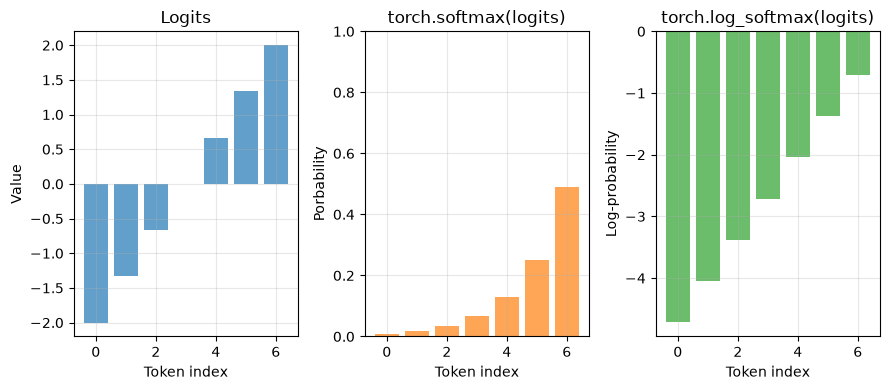

In [23]:
plt.figure(figsize=(9, 4))

# logits
plt.subplot(1, 3, 1)
plt.bar(range(len(logits)), logits, color="C0", alpha=0.7)
plt.title("Logits")
plt.xlabel("Token index")
plt.ylabel("Value")
plt.grid(alpha=0.3)

# plot softmax probabilities
plt.subplot(1, 3, 2)
plt.bar(range(len(probas)), probas, color="C1", alpha=0.7)
plt.title("torch.softmax(logits)")
plt.xlabel("Token index")
plt.ylabel("Porbability")
plt.ylim(0, 1)
plt.grid(alpha=0.3)

plt.subplot(1, 3, 3)
plt.bar(range(len(log_probas)), log_probas, color="C2", alpha=0.7)
plt.title("torch.log_softmax(logits)")
plt.xlabel("Token index")
plt.ylabel("Log-probability")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("logits_softmax_log_softmax.pdf")
plt.show()

In [27]:
@torch.inference_mode()
def calc_next_token_logprobas(model, tokenizer, prompt, device, show=True):
    token_ids = torch.tensor(tokenizer.encode(prompt), device=device)
    
    logits = model(token_ids.unsqueeze(0)).squeeze(0)
    all_logprobas = torch.log_softmax(logits, dim=-1)

    t_idx = torch.arange(0, token_ids.shape[0] - 1, device=device)
    next_ids = token_ids[1:]
    next_token_logprobas = all_logprobas[t_idx, next_ids]

    sum_next_token_logprobas = torch.sum(next_token_logprobas)

    if show:
        print("Next-token log-probabilities:", next_token_logprobas)
        print("Joint log-probability:", sum_next_token_logprobas)
    else:
        return next_token_logprobas, sum_next_token_logprobas

In [28]:
calc_next_token_logprobas(
    model, tokenizer, device=device,
    prompt="The capital of Japan is Tokyo"
)

Next-token log-probabilities: tensor([-9.6875, -0.7695, -3.9688, -0.3457, -0.7695], dtype=torch.bfloat16)
Joint log-probability: tensor(-15.5625, dtype=torch.bfloat16)


In [29]:
calc_next_token_logprobas(
    model, tokenizer, device=device,
    prompt="The capital of Japan is Osaka"
)

Next-token log-probabilities: tensor([-9.6875, -0.7695, -3.9688, -0.3457, -4.6562], dtype=torch.bfloat16)
Joint log-probability: tensor(-19.3750, dtype=torch.bfloat16)


In [30]:
example_prompt = "What is the capital of Japan?"
example_answer = " The capital of Japan is Tokyo."

next_token_logprobas, sum_next_token_logprobas = calc_next_token_logprobas(
    model, tokenizer, device=device,
    prompt=example_prompt+example_answer,
    show=False
)

print("Next-token logprobas:", next_token_logprobas)
print("Joint log-probability:", sum_next_token_logprobas)

Next-token logprobas: tensor([-0.4512, -0.3418, -8.3125, -0.3906, -4.4375, -3.3906, -1.8125,  0.0000,
        -0.0383,  0.0000, -0.0155, -0.2227, -0.2422], dtype=torch.bfloat16)
Joint log-probability: tensor(-19.6250, dtype=torch.bfloat16)


In [32]:
"""
We need to average log probabilities if we have answers with different length
also called per-token log-likelihood
"""
print(len(tokenizer.encode(example_answer)))

7


In [33]:
last_7 = next_token_logprobas[-7:]
print(last_7)
print(torch.mean(last_7))

tensor([-1.8125,  0.0000, -0.0383,  0.0000, -0.0155, -0.2227, -0.2422],
       dtype=torch.bfloat16)
tensor(-0.3340, dtype=torch.bfloat16)


In [34]:
@torch.inference_mode()
def avg_logprob_answer(model, tokenizer, prompt, answer, device="cpu"):
    prompt_ids = tokenizer.encode(prompt)
    answer_ids = tokenizer.encode(answer)
    full_ids = torch.tensor(prompt_ids + answer_ids, device=device)

    logits = model(full_ids.unsqueeze(0)).squeeze(0)
    logprobs = torch.log_softmax(logits, dim=-1)

    # index range for positions of answer tokens
    start = len(prompt_ids) - 1
    end = full_ids.shape[0] - 1

    t_idx = torch.arange(start, end, device=device)
    next_tokens = full_ids[start + 1 : end + 1]
    next_token_logps = logprobs[t_idx, next_tokens]

    # average over the answer token scores
    return torch.mean(next_token_logps)

In [35]:
score_1 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Japan?",
    answer=" The capital of Japan is Tokyo.",
    device=device
)
score_1

tensor(-0.3340, dtype=torch.bfloat16)

In [36]:
score_2 = avg_logprob_answer(
    model, tokenizer,
    prompt="What is the capital of Japan?",
    answer=" The capital of Japan is Osaka.",
    device=device
)
score_2

tensor(-1.6641, dtype=torch.bfloat16)

In [39]:
raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "Waht is the value of $x$?"
)
prompt = render_prompt(raw_prompt)

torch.manual_seed(123)
initial_response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 \boxed{18}

In [40]:
"""
In self-refinement, a critique can be useful even if parts
of it are wrong, as long as it pushes the model toward a better revision overall
"""

'\nIn self-refinement, a critique can be useful even if parts\nof it are wrong, as long as it pushes the model toward a better revision overall\n'

In [41]:
def make_critique_prompt(raw_prompt, draft):
    return (
        "You are a meticulous reviewer. Identify logical erros, missing "
        "steps, or arithmetic mistakes. If the answer seems correct, "
        "say so briefly. If seems incorrect propose a concise plan to fix issues.\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Draft answer:\n{draft}\n\n"
        "Write a short critique and bullet-point fix plan "
        "(under ~120 words).\n"
        "Critique:"
    )

critique_prompt = make_critique_prompt(raw_prompt, initial_response)

torch.manual_seed(123)
critique = generate_text_stream_concat_flex(
    model, tokenizer, critique_prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9,
)

 The solution seems to have a logical error in the setup of the equation. The equation should be set up such that the half of $3x-9$ equals $x+37$, not $x-37$. The proposed solution does not follow this logic.

Fix plan: First, solve the equation $3x-9 = 2(x+37)$, which simplifies to $3x-9 = 2x+74$. Subtracting $2x$ from both sides gives $x-9 = 74$. Adding $9$ to both sides results in $x = 83$.

In [44]:
def make_refine_prompt(raw_prompt, draft, critique):
    return (
        "Revise the answer using the critique. Keep it concise and "
        "end with a final boxed result: \\boxed{ANSWER}\n\n"
        f"Question:\n{raw_prompt}\n\n"
        f"Previous answer:\n{draft}\n\n"
        f"Critique:\n{critique}\n\n"
        "Revised answer:"
    )

refine_prompt = make_refine_prompt(raw_prompt, initial_response, critique)

torch.manual_seed(123)
revised_answer = generate_text_stream_concat_flex(
    model, tokenizer, refine_prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.7,
    top_p=0.9
)

 \boxed{83}

Answer:
 \boxed{83}

In [57]:
"""
Combined steps from previous code
Prompt -> Draft answer (might be wrong) score it
-> Critique the draft into prompt then critique -> refine prompt with raw_prompt, draft, critique
-> Score the revised answer -> compare the scores from first draft to revised

Taking input coming up with a draft answer
then analyzing the draft, take the analyzed answer and critique it all
all steps being re-feed into an LLM
"""
def self_refinement_loop(
    model,
    tokenizer,
    raw_prompt,
    device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=None,
    prompt_renderer=render_prompt,
    prompt_suffix="",
    verbose=False,
    temperature=0.7,
    top_p=0.9,
):
    steps = []
    # inital response (draft)
    prompt = prompt_renderer(raw_prompt) + prompt_suffix
    current_full = generate_text_stream_concat_flex(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        device=device,
        max_new_tokens=max_response_tokens,
        verbose=False,
        generate_func=generate_text_top_p_stream_cache,
        temperature=temperature,
        top_p=top_p,
    )

    current_extracted = extract_final_candidate(
        current_full, fallback="number_then_full"
    )

    if score_fn:
        current_score = score_fn(answer=current_full, prompt=prompt)
    else:
        current_score = 0.0

    for i in range(iterations):
        draft_before_full = current_full
        draft_before_extracted = current_extracted
        score_before = current_score

        critique_prompt = make_critique_prompt(
            raw_prompt, draft_before_full
        )
        critique_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=critique_prompt,
            device=device,
            max_new_tokens=max_critique_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )

        refine_prompt = make_refine_prompt(
            raw_prompt, draft_before_full, critique_full
        )
        revised_full = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=refine_prompt,
            device=device,
            max_new_tokens=max_response_tokens,
            verbose=False,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )

        revised_extracted = extract_final_candidate(
            revised_full, fallback="number_then_full"
        )

        if score_fn:
            revised_score = score_fn(answer=revised_full, prompt=prompt)
        else:
            revised_score = 0.0

        step = {
            "iteration": i + 1,
            "draft_full": draft_before_full,
            "draft_extracted": draft_before_extracted,
            "critique": critique_full,
            "revised_full": revised_full,
            "revised_extracted": revised_extracted,
            "score_before": score_before,
            "score_after": revised_score,
        }
        steps.append(step)

        if verbose:
            print(
                f"[Refinement {i+1}/{iterations}]"
                f"\nCurrent: {draft_before_extracted}"
                f"\nRevised: {revised_extracted}"
                f"\nScore before: {score_before:.3f}"
                f"\nScore after: {revised_score:.3f}"
                f"\n{'=' * 25}\n"
            )
            
        if revised_score >= current_score:
            current_full = revised_full
            current_extracted = revised_extracted
            current_score = revised_score

    return {
        "final_full": current_full,
        "final_extracted": current_extracted,
        "steps": steps,
    }

In [58]:
from functools import partial

avg_logprob_score = partial(
    avg_logprob_answer,
    model=model,
    tokenizer=tokenizer,
    device=device
)

In [59]:
torch.manual_seed(1)
results_logprob = self_refinement_loop(
    model=model,
    tokenizer=tokenizer,
    raw_prompt=raw_prompt,
    device=device,
    iterations=2,
    max_response_tokens=2048,
    max_critique_tokens=256,
    score_fn=avg_logprob_score,
    verbose=True,
    temperature=0.7,
    top_p=0.9,
)

[Refinement 1/2]
Current: 83
Revised: 83
Score before: -0.071
Score after: -1.406

[Refinement 2/2]
Current: 83
Revised: 83
Score before: -0.071
Score after: -1.633



In [60]:
results_logprob["final_extracted"]

'83'

In [62]:
print(results_logprob["final_full"])

 Let's solve the problem step by step.

1. **Understand the given information:**
   - Half the value of \( 3x - 9 \) is equal to \( x + 37 \).
   - We need to find the value of \( x \).

2. **Translate the given information into an equation:**
   - Half the value of \( 3x - 9 \) means \( \frac{1}{2} \times (3x - 9) \).
   - According to the problem, this is equal to \( x + 37 \).

3. **Set up the equation:**
   \[
   \frac{1}{2} \times (3x - 9) = x + 37
   \]

4. **Simplify the left side of the equation:**
   \[
   \frac{3x - 9}{2} = x + 37
   \]

5. **Eliminate the fraction by multiplying both sides by 2:**
   \[
   3x - 9 = 2(x + 37)
   \]

6. **Distribute the 2 on the right side:**
   \[
   3x - 9 = 2x + 74
   \]

7. **Isolate \( x \) by subtracting \( 2x \) from both sides:**
   \[
   3x - 2x - 9 = 74
   \]
   \[
   x - 9 = 74
   \]

8. **Solve for \( x \) by adding 9 to both sides:**
   \[
   x = 74 + 9
   \]
   \[
   x = 83
   \]

9. **Final Answer:**
   \[
   \boxed{83}
   \]
